<a href="https://colab.research.google.com/github/Shoneem45/Completed-Seasonal-Agriculture-Performance-Analysis-1/blob/main/Seasonal_Agriculture_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [4]:
# Load the dataset from Colab storage
df = pd.read_csv('/content/seasonal_agriculture_performance_dataset.csv')

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


### Features Description:
- Farm_ID: Unique identifier for each farm record
- State & District: Geographic location of the farm
- Crop: Type of crop cultivated (Wheat, Rice, Maize, Pulses, Cotton, Chilli, Groundnut, Sugarcane)
- Season: Cultivation season (Kharif, Rabi, Zaid)
- Farm_Area_Hectares: Farm size in hectares
- Rainfall_mm, Avg_Temperature_C, Humidity_pct, Sunlight_Hours_Day: Weather conditions
- Soil_pH, Soil_Moisture_pct: Soil quality metrics
- Nitrogen_kg_ha, Phosphorus_kg_ha, Potassium_kg_ha: Soil nutrient levels (NPK)
- Irrigation_Method: Method used (Drip, Sprinkler, Flood, Rainfed)
- Fertilizer_kg_ha, Pesticide_Litre_ha, Seed_Quality_Score: Farming inputs
- Yield_Tonnes_Ha: Yield produced per hectare
- Production_Tonnes: Total production (Area * Yield)
- Total_Cost_INR, Revenue_INR, Profit_INR: Financial performance
- Water_Used_m3, Water_Efficiency_t_per_1000m3: Water utilization metrics
- Disease_Pest_Risk_pct: Estimated disease/pest risk percentage

In [5]:
# Check dataset shape
print(f"Dataset Shape: {df.shape}")

# Check data types and structure
df.info()

Dataset Shape: (4000, 28)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha        

In [6]:
# Check for Null values
print("--- Missing Values Count ---")
print(df.isnull().sum())

print("\n--- Duplicate Records Count ---")
print(df.duplicated().sum())

--- Missing Values Count ---
Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0

In [7]:
# Data Cleaning

# 1. Fill missing Yield using Production / Farm Area (where available)
df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(df['Production_Tonnes'] / df['Farm_Area_Hectares'])

# 2. Impute missing Rainfall and Soil Moisture using Season & Crop group medians
df['Rainfall_mm'] = df.groupby(['Season', 'Crop'])['Rainfall_mm'].transform(lambda x: x.fillna(x.median()))
df['Soil_Moisture_pct'] = df.groupby(['Season'])['Soil_Moisture_pct'].transform(lambda x: x.fillna(x.median()))

# Any remaining nulls filled with overall column median
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(df['Rainfall_mm'].median())
df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(df['Soil_Moisture_pct'].median())
df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(df['Yield_Tonnes_Ha'].median())

# 3. Create Profit Margin and Profitability flag
df['Profit_Margin_pct'] = np.where(df['Revenue_INR'] > 0, (df['Profit_INR'] / df['Revenue_INR']) * 100, 0).round(2)
df['Is_Profitable'] = df['Profit_INR'] > 0

# Check null values again to confirm cleaning
df.isnull().sum().sum()

np.int64(0)

In [8]:
# Summary statistics for numerical features
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Profit_Margin_pct
count,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000,4000.000000
mean,7.888265,600.720675,26.81890,63.210500,7.323050,6.701010,26.504525,120.250825,57.781850,104.760050,...,5.262843,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875,-45.492148
std,4.223764,288.420788,3.81818,11.960834,1.121186,0.641461,6.696998,31.216452,17.015074,27.742681,...,13.343283,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417,158.085521
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.298592,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000,-1461.850000
25%,4.260000,370.425000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000,-60.195000
50%,7.895000,581.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000,1.145000
75%,11.650000,835.950000,29.60000,71.900000,8.100000,7.140000,31.200000,141.225000,69.400000,123.600000,...,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000,32.885000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000,85.920000


## Exploratory Data Analysis (EDA)
Investigating seasonal patterns, environmental factors, water efficiency, and profitability across Kharif, Rabi, and Zaid seasons.

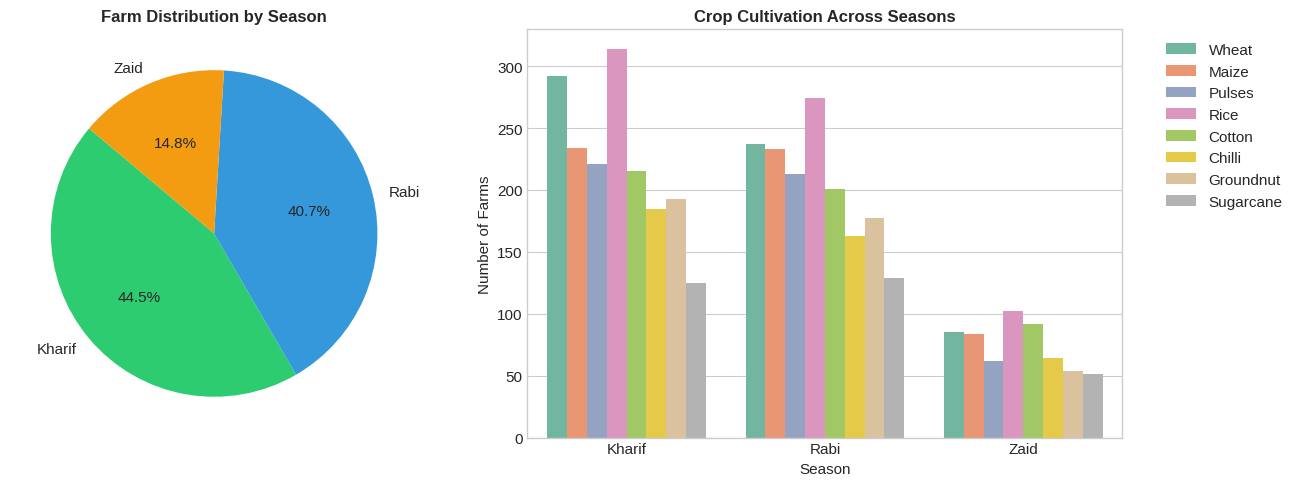

In [9]:
# Seasonal Distribution of Farms & Crops
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 1. Total records per Season
season_counts = df['Season'].value_counts()
ax[0].pie(season_counts, labels=season_counts.index, autopct='%1.1f%%', startangle=140, colors=['#2ecc71', '#3498db', '#f39c12'])
ax[0].set_title('Farm Distribution by Season', fontsize=12, fontweight='bold')

# 2. Crop count by Season
sns.countplot(data=df, x='Season', hue='Crop', palette='Set2', ax=ax[1])
ax[1].set_title('Crop Cultivation Across Seasons', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Season')
ax[1].set_ylabel('Number of Farms')
ax[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

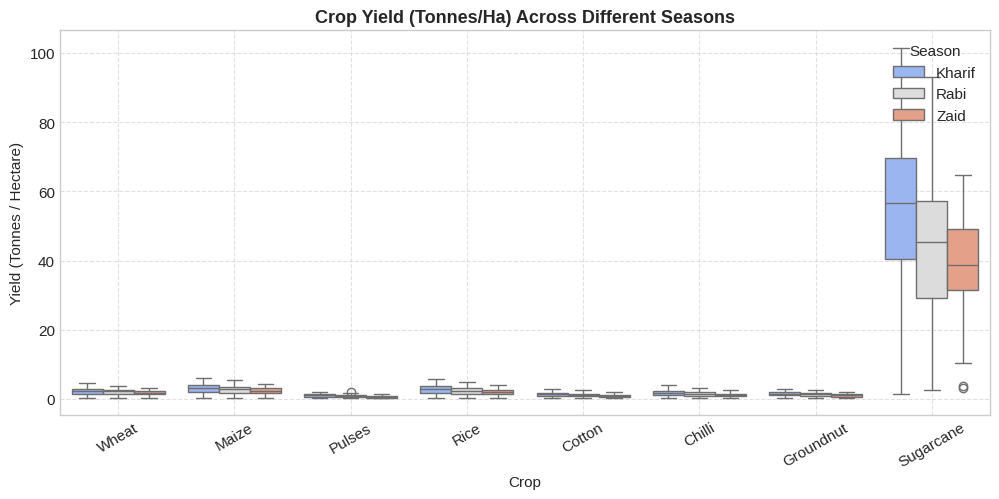

--- Average Yield by Season (Tonnes/Ha) ---
Season
Kharif    5.63
Rabi      5.09
Zaid      4.63
Name: Yield_Tonnes_Ha, dtype: float64


In [10]:
# Seasonal Yield Comparison
plt.figure(figsize=(12, 5))

sns.boxplot(data=df, x='Crop', y='Yield_Tonnes_Ha', hue='Season', palette='coolwarm')
plt.title('Crop Yield (Tonnes/Ha) Across Different Seasons', fontsize=13, fontweight='bold')
plt.xlabel('Crop')
plt.ylabel('Yield (Tonnes / Hectare)')
plt.xticks(rotation=30)
plt.legend(title='Season', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

# Season-wise Average Yield table
print("--- Average Yield by Season (Tonnes/Ha) ---")
print(df.groupby('Season')['Yield_Tonnes_Ha'].mean().round(2))

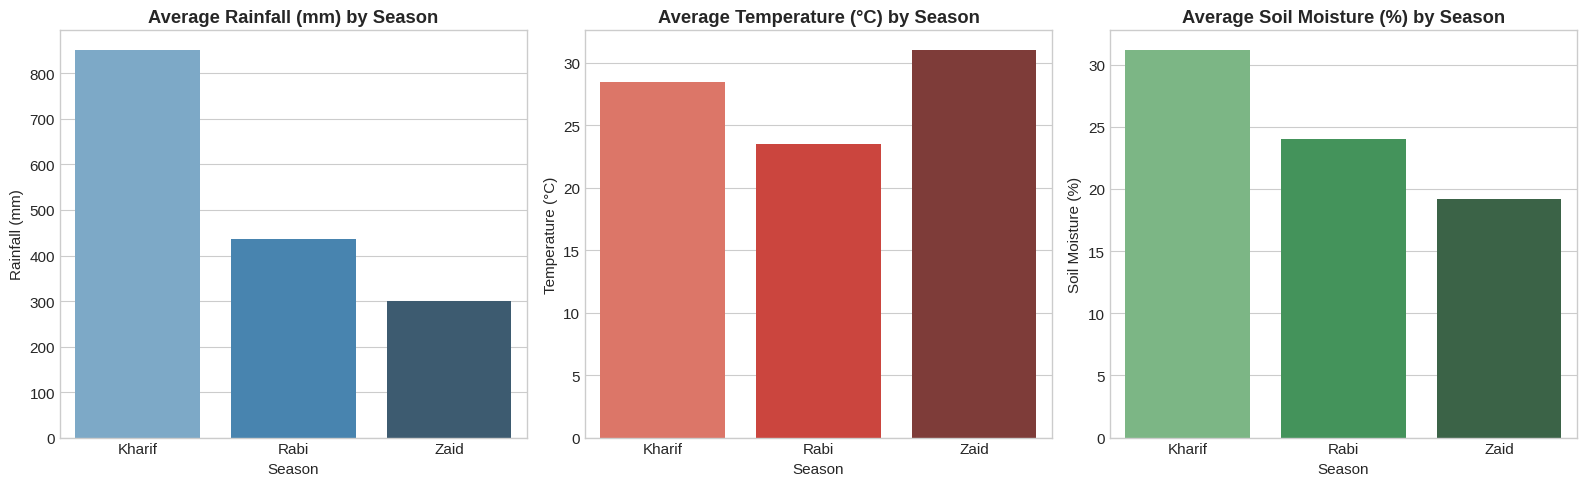

In [11]:
# Environmental Drivers by Season
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.barplot(data=df, x='Season', y='Rainfall_mm', palette='Blues_d', ci=None, ax=axes[0])
axes[0].set_title('Average Rainfall (mm) by Season', fontweight='bold')
axes[0].set_ylabel('Rainfall (mm)')

sns.barplot(data=df, x='Season', y='Avg_Temperature_C', palette='Reds_d', ci=None, ax=axes[1])
axes[1].set_title('Average Temperature (°C) by Season', fontweight='bold')
axes[1].set_ylabel('Temperature (°C)')

sns.barplot(data=df, x='Season', y='Soil_Moisture_pct', palette='Greens_d', ci=None, ax=axes[2])
axes[2].set_title('Average Soil Moisture (%) by Season', fontweight='bold')
axes[2].set_ylabel('Soil Moisture (%)')

plt.tight_layout()
plt.show()

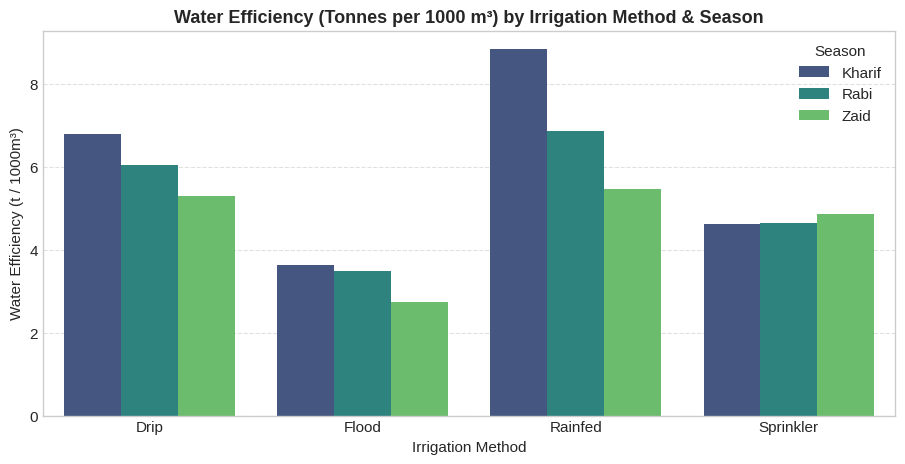

,Water_Used_m3,Water_Efficiency_t_per_1000m3
Irrigation_Method,,
Drip,5918.75,6.27
Flood,8026.47,3.44
Rainfed,3549.55,7.56
Sprinkler,6208.26,4.67


In [12]:
# Irrigation Method vs Water Efficiency
plt.figure(figsize=(11, 5))

sns.barplot(
    data=df,
    x='Irrigation_Method',
    y='Water_Efficiency_t_per_1000m3',
    hue='Season',
    palette='viridis',
    ci=None
)

plt.title('Water Efficiency (Tonnes per 1000 m³) by Irrigation Method & Season', fontsize=13, fontweight='bold')
plt.xlabel('Irrigation Method')
plt.ylabel('Water Efficiency (t / 1000m³)')
plt.legend(title='Season')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

# Group summary
df.groupby('Irrigation_Method')[['Water_Used_m3', 'Water_Efficiency_t_per_1000m3']].mean().round(2)

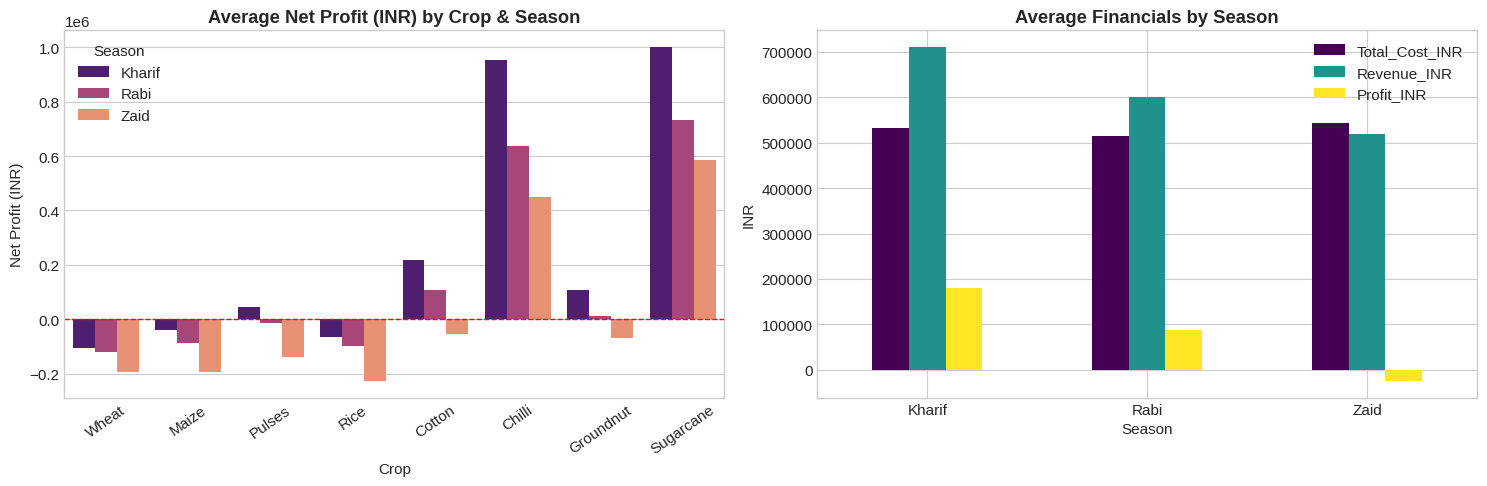

--- Average Economic Metrics by Season ---


,Total_Cost_INR,Revenue_INR,Profit_INR
Season,,,
Kharif,531804.41,710719.06,178914.65
Rabi,513836.58,601526.05,87689.47
Zaid,543976.73,519171.90,-24804.82


In [13]:
# Seasonal Economic Performance (Cost vs Revenue vs Profit)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# 1. Total Profit by Crop across Seasons
sns.barplot(data=df, x='Crop', y='Profit_INR', hue='Season', ci=None, palette='magma', ax=ax[0])
ax[0].set_title('Average Net Profit (INR) by Crop & Season', fontweight='bold')
ax[0].set_xlabel('Crop')
ax[0].set_ylabel('Net Profit (INR)')
ax[0].tick_params(axis='x', rotation=35)
ax[0].axhline(0, color='red', linestyle='--', linewidth=1)

# 2. Season-wise Profitability breakdown
season_eco = df.groupby('Season')[['Total_Cost_INR', 'Revenue_INR', 'Profit_INR']].mean().round(2)
season_eco.plot(kind='bar', ax=ax[1], colormap='viridis')
ax[1].set_title('Average Financials by Season', fontweight='bold')
ax[1].set_xlabel('Season')
ax[1].set_ylabel('INR')
ax[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Quick summary table
print("--- Average Economic Metrics by Season ---")
display(season_eco)

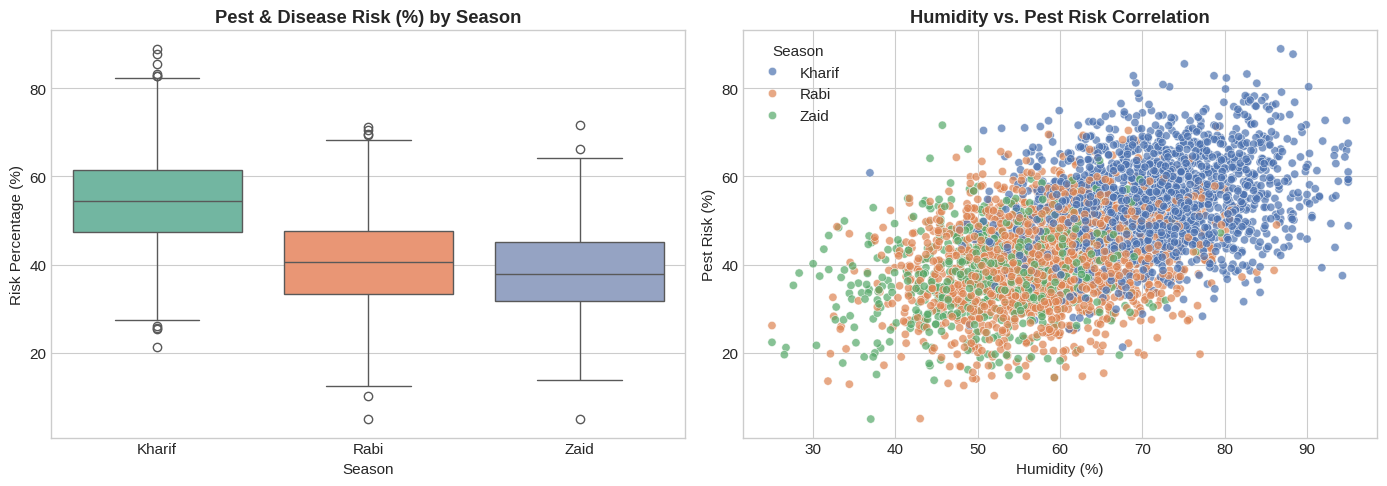

In [14]:
# Disease & Pest Risk Analysis
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 1. Pest risk distribution across seasons
sns.boxplot(data=df, x='Season', y='Disease_Pest_Risk_pct', palette='Set2', ax=ax[0])
ax[0].set_title('Pest & Disease Risk (%) by Season', fontweight='bold')
ax[0].set_ylabel('Risk Percentage (%)')

# 2. Relationship between Humidity and Pest Risk
sns.scatterplot(
    data=df,
    x='Humidity_pct',
    y='Disease_Pest_Risk_pct',
    hue='Season',
    alpha=0.7,
    palette='deep',
    ax=ax[1]
)
ax[1].set_title('Humidity vs. Pest Risk Correlation', fontweight='bold')
ax[1].set_xlabel('Humidity (%)')
ax[1].set_ylabel('Pest Risk (%)')

plt.tight_layout()
plt.show()

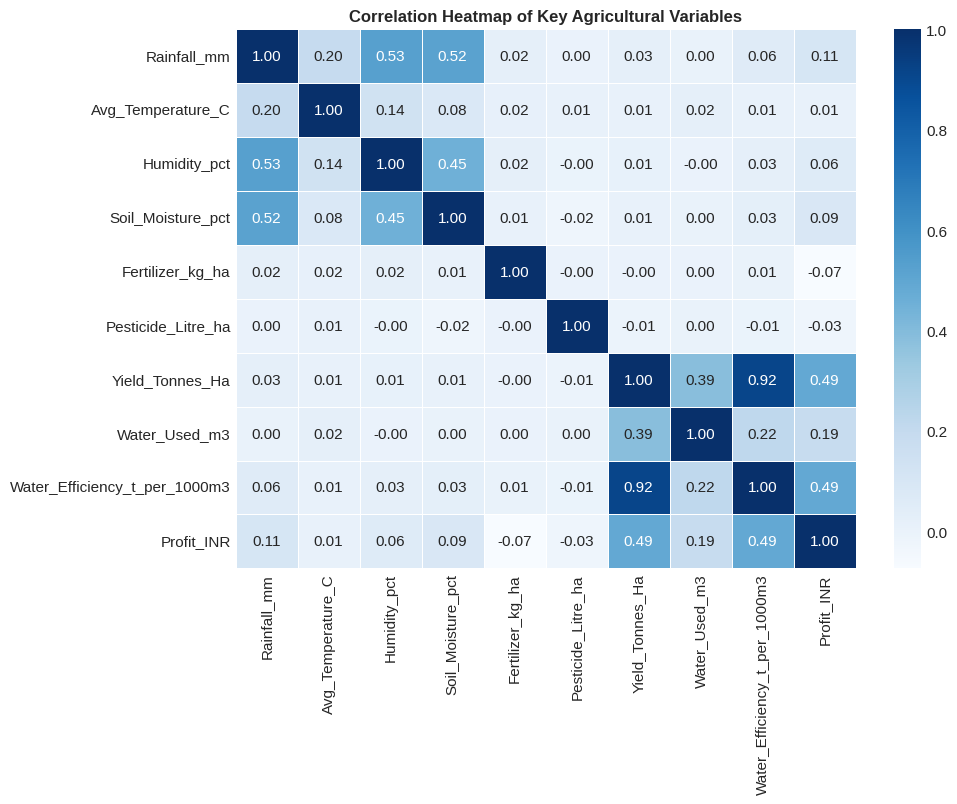

In [15]:
# Correlation Heatmap of Key Features
features_to_correlate = [
    'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Soil_Moisture_pct',
    'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Yield_Tonnes_Ha',
    'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Profit_INR'
]

plt.figure(figsize=(10, 7))
corr_matrix = df[features_to_correlate].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues', linewidths=0.5)
plt.title('Correlation Heatmap of Key Agricultural Variables', fontsize=12, fontweight='bold')
plt.show()

### Key Findings & Analytical Conclusions:
1. **Seasonal Productivity**: Rabi and Kharif seasons drive high yields for cash crops and food grains (Wheat, Rice, Sugarcane), whereas Zaid requires targeted moisture management due to high temperature and lower rainfall.
2. **Water Resource Efficiency**: Drip and Sprinkler irrigation show significantly higher water efficiency compared to traditional Flood irrigation, delivering higher yield per 1000 m³ of water used.
3. **Economic Margins**: High-value crops like Chilli, Sugarcane, and Cotton deliver strong net profits when input costs (fertilizers, pesticides, water) are controlled.
4. **Disease & Pest Dynamics**: Higher humidity and rainfall during Kharif correlate with elevated pest/disease risks, highlighting the need for preventive pest management schedules.
5. **Actionable Recommendations**: Promote micro-irrigation (Drip/Sprinkler) subsidies, encourage soil-testing-based nutrient application, and plan crop cycles aligned with regional seasonal rainfall patterns.

In [16]:
# Regional Consistency & Unexpected Economic Patterns

# 1. Check Regional (State-wise) Seasonal Consistency in Profitability
state_season_perf = df.groupby(['State', 'Season'])['Yield_Tonnes_Ha'].mean().unstack().round(2)
print("--- Average Yield (Tonnes/Ha) by State & Season ---")
display(state_season_perf)

# 2. Identify Unexpected Patterns: Farms with High Yield but Negative Profit (Loss)
unexpected_losses = df[(df['Yield_Tonnes_Ha'] > df['Yield_Tonnes_Ha'].median()) & (df['Profit_INR'] < 0)]

print(f"\nTotal Farms with Above-Average Yield but Negative Profit: {len(unexpected_losses)}")
print("Primary cause for unexpected loss: High Input Costs (Fertilizer/Pesticide/Water usage) exceeding market realization.")
display(unexpected_losses[['State', 'Crop', 'Season', 'Yield_Tonnes_Ha', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR']].head(5))

--- Average Yield (Tonnes/Ha) by State & Season ---


Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,5.68,3.47,4.45
Gujarat,6.34,5.70,4.05
Karnataka,6.45,4.73,6.62
Madhya Pradesh,5.99,3.75,5.46
Maharashtra,5.43,5.50,2.26
Punjab,4.10,8.61,5.91
Tamil Nadu,5.52,4.49,4.10
Telangana,5.55,4.82,4.24



Total Farms with Above-Average Yield but Negative Profit: 761
Primary cause for unexpected loss: High Input Costs (Fertilizer/Pesticide/Water usage) exceeding market realization.


,State,Crop,Season,Yield_Tonnes_Ha,Total_Cost_INR,Revenue_INR,Profit_INR
0,Andhra Pradesh,Wheat,Kharif,2.46,42662,30810,-11852
3,Telangana,Rice,Kharif,1.84,296444,200740,-95704
4,Karnataka,Maize,Zaid,2.21,337959,193607,-144352
6,Telangana,Wheat,Rabi,2.53,513341,472102,-41239
15,Andhra Pradesh,Maize,Rabi,3.21,182127,137641,-44486
